# Bayesian Wind-Tunnel Analysis for Tetris Rotation (Pipeline-Compatible)

This notebook creates a **Bayesian wind tunnel** for the Tetris rotation setup used in `pipeline_tetris.ipynb`.  
We generate synthetic Tetris shapes, reveal them through **partial rotation steps**, and compute the **exact Bayesian posterior** over `(shape, angle)` after each observation.  

We then compare that ground-truth posterior to a **coarser observer** (a proxy for a model that loses information), and measure entropy calibration error across steps.

You can later replace the coarse observer with your actual model (FM / PPO / DINO-based) by plugging its likelihood into the `model_log_likelihood(...)` function.

In [40]:
%cd /Users/masha/Documents/visual-reasoning

/Users/masha/Documents/visual-reasoning


In [41]:
import math
from typing import Dict, Tuple, List

import numpy as np
import cv2
import matplotlib.pyplot as plt

# Reproducibility
SEED = 0
rng = np.random.default_rng(SEED)

# Global config
IMG_SIZE = 64
ANGLE_STEP = 10
ANGLES = list(range(0, 360, ANGLE_STEP))
N_STEPS = 8  # number of partial observations in the trajectory
SIGMA_TRUE = 0.06  # noise scale for ground-truth likelihood
SIGMA_MODEL = 0.10  # noise scale for coarse observer
COARSE_SIZE = 16  # downsample size for coarse observer

In [42]:
# --- Tetris chiral shapes (same family as pipeline_tetris) ---
CHIRAL_SHAPES = {
    'L': [(0, -1), (0, 0), (0, 1), (1, 1)],
    'J': [(0, -1), (0, 0), (0, 1), (-1, 1)],
    'S': [(0, 0), (1, 0), (0, 1), (-1, 1)],
    'Z': [(0, 0), (-1, 0), (0, 1), (1, 1)],
    'F': [(0, 0), (0, -1), (1, -1), (-1, 0), (0, 1)],
    'P': [(0, 0), (0, -1), (1, -1), (1, 0), (0, 1)],
}

SHAPE_KEYS = list(CHIRAL_SHAPES.keys())


def draw_shape_np(name: str, size: int = IMG_SIZE) -> np.ndarray:
    img = np.zeros((size, size), dtype=np.uint8)
    center = size // 2
    block_size = size // 8
    for dx, dy in CHIRAL_SHAPES[name]:
        x = center + (dx * block_size) - (block_size // 2)
        y = center + (dy * block_size) - (block_size // 2)
        cv2.rectangle(img, (x, y), (x + block_size, y + block_size), 255, -1)
    return img


def rotate_image(img: np.ndarray, angle_deg: float, bg: int = 0) -> np.ndarray:
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=bg)


def make_trajectory(shape_name: str, angle_deg: float, steps: int = N_STEPS) -> List[np.ndarray]:
    base = draw_shape_np(shape_name, IMG_SIZE)
    fracs = np.linspace(0.0, 1.0, steps)
    frames = [rotate_image(base, angle_deg * f) for f in fracs]
    return frames

In [43]:
# --- Hypothesis bank ---

def build_hypothesis_bank(shape_keys: List[str], angles: List[int], size: int) -> Dict[Tuple[str, int], np.ndarray]:
    bank = {}
    for s in shape_keys:
        base = draw_shape_np(s, size)
        for a in angles:
            bank[(s, a)] = rotate_image(base, a)
    return bank


def downsample(img: np.ndarray, size: int) -> np.ndarray:
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)


HYP_BANK = build_hypothesis_bank(SHAPE_KEYS, ANGLES, IMG_SIZE)
HYP_BANK_COARSE = {k: downsample(v, COARSE_SIZE) for k, v in HYP_BANK.items()}

In [44]:
# --- Bayesian update utilities ---

def img_float(img: np.ndarray) -> np.ndarray:
    return img.astype(np.float32) / 255.0


def log_likelihood(obs: np.ndarray, hyp: np.ndarray, sigma: float) -> float:
    diff = img_float(obs) - img_float(hyp)
    mse = float(np.mean(diff ** 2))
    return -mse / (2.0 * sigma * sigma)


def normalize_log_probs(logp: np.ndarray) -> np.ndarray:
    m = np.max(logp)
    exp = np.exp(logp - m)
    return exp / np.sum(exp)


def posterior_update(prior: np.ndarray, obs: np.ndarray, bank: List[np.ndarray], sigma: float) -> np.ndarray:
    # bank is list of hypothesis images aligned with prior
    logp = np.array([math.log(max(p, 1e-12)) + log_likelihood(obs, hyp, sigma) for p, hyp in zip(prior, bank)])
    return normalize_log_probs(logp)


def entropy_bits(p: np.ndarray) -> float:
    p = np.clip(p, 1e-12, 1.0)
    return float(-np.sum(p * np.log2(p)))

In [45]:
# --- Prepare aligned hypothesis lists for fast updates ---
HYP_KEYS = list(HYP_BANK.keys())
HYP_LIST = [HYP_BANK[k] for k in HYP_KEYS]
HYP_LIST_COARSE = [HYP_BANK_COARSE[k] for k in HYP_KEYS]


def uniform_prior(n: int) -> np.ndarray:
    return np.ones(n, dtype=np.float64) / n

In [46]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torchvision import transforms

# Device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

In [47]:
# --- FM rotator (from pipeline_tetris.ipynb) ---
MODEL_PATH = "models/rotator_l1_500e_10k.pth"
FM_STEPS = 8
FM_SIGMA = 0.12  # likelihood noise scale (tune if needed)

FM_TUNE = True
FM_SIGMA_CANDIDATES = [0.06, 0.08, 0.10, 0.12, 0.15, 0.18]
FM_TUNE_SAMPLES = 6

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class FastRotator(nn.Module):
    def __init__(self, backbone_dim=384, flow_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim*4), nn.GELU(), nn.Linear(flow_dim*4, flow_dim*4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim*4), nn.GELU(), nn.Linear(flow_dim*4, flow_dim*4))
        self.cond_proj = nn.Linear(backbone_dim, flow_dim*4)

        self.inc = DoubleConv(1, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim*2, flow_dim*4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim*6, flow_dim*2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim*3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, x_t, t, dino_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        d_emb = self.cond_proj(dino_emb)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        global_cond = (t_emb + d_emb + a_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)

fm_model = FastRotator().to(DEVICE)
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)
fm_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
fm_model.eval()
for p in fm_model.parameters():
    p.requires_grad = False

# DINO backbone for conditioning
try:
    dino = timm.create_model("vit_small_patch16_dinov3", pretrained=True).to(DEVICE).eval()
    for p in dino.parameters():
        p.requires_grad = False
except Exception as e:
    print("Could not load DINO weights:", e)
    dino = None

In [48]:
@torch.no_grad()
def get_dino_embedding(img_64_tensor: torch.Tensor, dino_model: nn.Module) -> torch.Tensor:
    # img_64_tensor: (B, 1, 64, 64) in [-1, 1]
    img = (img_64_tensor * 0.5) + 0.5
    img = F.interpolate(img, size=(224, 224), mode='bilinear', align_corners=False)
    img = img.repeat(1, 3, 1, 1)
    norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    img = norm(img)
    emb = dino_model.forward_features(img)[:, 0, :]
    return emb


@torch.no_grad()
def apply_rotation_fm(model, base_img, base_emb, angle_deg, steps=10):
    # base_img: (B, 1, 64, 64) in [-1, 1]
    model.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]
    target_ang = torch.full((B, 1), float(angle_deg), device=base_img.device, dtype=base_img.dtype)
    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=base_img.device, dtype=base_img.dtype)
        v1 = model(curr, t, base_emb, target_ang)
        mid = curr + v1 * dt
        t2 = torch.full((B, 1), (i + 1) / steps, device=base_img.device, dtype=base_img.dtype)
        v2 = model(mid, t2, base_emb, target_ang)
        curr = curr + 0.5 * (v1 + v2) * dt
    curr = torch.nan_to_num(curr, nan=0.0, posinf=1.0, neginf=-1.0)
    curr = curr.clamp(-1.0, 1.0)
    return curr

In [49]:
# --- FM helpers ---

def np_to_fm_tensor(img_np: np.ndarray, device: torch.device) -> torch.Tensor:
    t = torch.from_numpy(img_np.astype(np.float32) / 255.0).unsqueeze(0).unsqueeze(0).to(device)
    return t * 2.0 - 1.0


# Precompute base tensors + DINO embeddings per shape
SHAPE_BASE_TENSOR = {}
SHAPE_BASE_EMB = {}

if dino is not None:
    for s in SHAPE_KEYS:
        base = draw_shape_np(s, IMG_SIZE)
        base_t = np_to_fm_tensor(base, DEVICE)
        SHAPE_BASE_TENSOR[s] = base_t
        SHAPE_BASE_EMB[s] = get_dino_embedding(base_t, dino)

In [50]:
@torch.no_grad()
def fm_log_likelihood(obs_np: np.ndarray, shape_key: str, angle_deg: float, frac: float, sigma: float = None) -> float:
    if dino is None:
        raise RuntimeError("DINO model not loaded. Set up weights or skip FM observer.")
    obs_t = np_to_fm_tensor(obs_np, DEVICE)
    base_t = SHAPE_BASE_TENSOR[shape_key]
    base_emb = SHAPE_BASE_EMB[shape_key]
    pred = apply_rotation_fm(fm_model, base_t, base_emb, angle_deg * frac, steps=FM_STEPS)
    diff = pred - obs_t
    mse = float(diff.pow(2).mean().item())
    sigma = FM_SIGMA if sigma is None else sigma
    return -mse / (2.0 * sigma * sigma)


def posterior_update_fm(prior: np.ndarray, obs_np: np.ndarray, step_frac: float, sigma: float = None) -> np.ndarray:
    logp = []
    for p, (shape_key, angle) in zip(prior, HYP_KEYS):
        ll = fm_log_likelihood(obs_np, shape_key, angle, step_frac, sigma=sigma)
        logp.append(math.log(p) + ll)
    return normalize_log_probs(np.array(logp))

In [51]:
# --- FM sigma tuning (optional, slow) ---
if FM_TUNE:
    fracs = np.linspace(0.0, 1.0, N_STEPS)
    best_sigma = FM_SIGMA
    best_mae = float('inf')
    for sigma in FM_SIGMA_CANDIDATES:
        ent_true_all = []
        ent_fm_all = []
        for _ in range(FM_TUNE_SAMPLES):
            shape = rng.choice(SHAPE_KEYS)
            angle = int(rng.choice(ANGLES))
            frames = make_trajectory(shape, angle, steps=N_STEPS)
            p_true = uniform_prior(len(HYP_KEYS))
            p_fm = uniform_prior(len(HYP_KEYS))
            ent_true = []
            ent_fm = []
            for obs, frac in zip(frames, fracs):
                p_true = posterior_update(p_true, obs, HYP_LIST, SIGMA_TRUE)
                p_fm = posterior_update_fm(p_fm, obs, frac, sigma=sigma)
                ent_true.append(entropy_bits(p_true))
                ent_fm.append(entropy_bits(p_fm))
            ent_true_all.append(ent_true)
            ent_fm_all.append(ent_fm)
        ent_true_all = np.array(ent_true_all)
        ent_fm_all = np.array(ent_fm_all)
        mean_true = ent_true_all.mean(axis=0)
        mean_fm = ent_fm_all.mean(axis=0)
        mae = np.mean(np.abs(mean_true - mean_fm))
        print(f"sigma={sigma:.3f} -> MAE={mae:.3f}")
        if mae < best_mae:
            best_mae = mae
            best_sigma = sigma
    FM_SIGMA = best_sigma
    print(f"Best FM_SIGMA={FM_SIGMA:.3f} (MAE={best_mae:.3f})")


sigma=0.060 -> MAE=1.340
sigma=0.080 -> MAE=1.467
sigma=0.100 -> MAE=1.325
sigma=0.120 -> MAE=1.314
sigma=0.150 -> MAE=1.234
sigma=0.180 -> MAE=1.728
Best FM_SIGMA=0.150 (MAE=1.234)


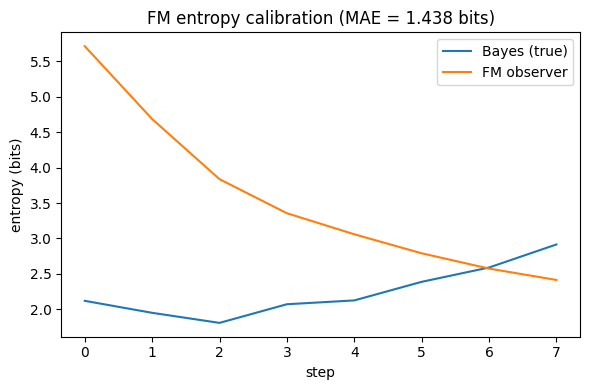

In [53]:
# --- FM observer evaluation (slow) ---

USE_FM = True
FM_EVAL_SAMPLES = 20  # reduce if slow

if USE_FM:
    ent_true_all = []
    ent_fm_all = []
    fracs = np.linspace(0.0, 1.0, N_STEPS)

    for _ in range(FM_EVAL_SAMPLES):
        shape = rng.choice(SHAPE_KEYS)
        angle = int(rng.choice(ANGLES))
        frames = make_trajectory(shape, angle, steps=N_STEPS)

        p_true = uniform_prior(len(HYP_KEYS))
        p_fm = uniform_prior(len(HYP_KEYS))

        ent_true = []
        ent_fm = []

        for obs, frac in zip(frames, fracs):
            p_true = posterior_update(p_true, obs, HYP_LIST, SIGMA_TRUE)
            p_fm = posterior_update_fm(p_fm, obs, frac)
            ent_true.append(entropy_bits(p_true))
            ent_fm.append(entropy_bits(p_fm))

        ent_true_all.append(ent_true)
        ent_fm_all.append(ent_fm)

    ent_true_all = np.array(ent_true_all)
    ent_fm_all = np.array(ent_fm_all)

    mean_true = ent_true_all.mean(axis=0)
    mean_fm = ent_fm_all.mean(axis=0)
    mae = np.mean(np.abs(mean_true - mean_fm))

    plt.figure(figsize=(6, 4))
    plt.plot(mean_true, label='Bayes (true)')
    plt.plot(mean_fm, label='FM observer')
    plt.xlabel("step")
    plt.ylabel("entropy (bits)")
    plt.title(f"FM entropy calibration (MAE = {mae:.3f} bits)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## DINO-Only Baseline (No FM)

This uses **DINO embedding similarity** as the observer likelihood.  
It tests how much you can recover using just semantic similarity without explicit rotation dynamics.

In [ ]:
# --- DINO-only baseline ---
DINO_SIGMA = 0.35  # likelihood scale in embedding space (tune if needed)
DINO_EVAL_SAMPLES = 50

@torch.no_grad()
def dino_embed_from_np(img_np: np.ndarray) -> torch.Tensor:
    t = np_to_fm_tensor(img_np, DEVICE)  # (1,1,64,64) in [-1,1]
    return get_dino_embedding(t, dino)

# Precompute hypothesis embeddings once
HYP_DINO_EMB = None
if dino is not None:
    HYP_DINO_EMB = []
    for k in HYP_KEYS:
        emb = dino_embed_from_np(HYP_BANK[k])
        HYP_DINO_EMB.append(emb)

In [ ]:
@torch.no_grad()
def posterior_update_dino(prior: np.ndarray, obs_np: np.ndarray) -> np.ndarray:
    if dino is None or HYP_DINO_EMB is None:
        raise RuntimeError("DINO embeddings not available.")
    obs_emb = dino_embed_from_np(obs_np)
    logp = []
    for p, hyp_emb in zip(prior, HYP_DINO_EMB):
        diff = obs_emb - hyp_emb
        dist = float((diff * diff).sum().item())
        logp.append(math.log(max(p, 1e-12)) - dist / (2.0 * DINO_SIGMA * DINO_SIGMA))
    return normalize_log_probs(np.array(logp))

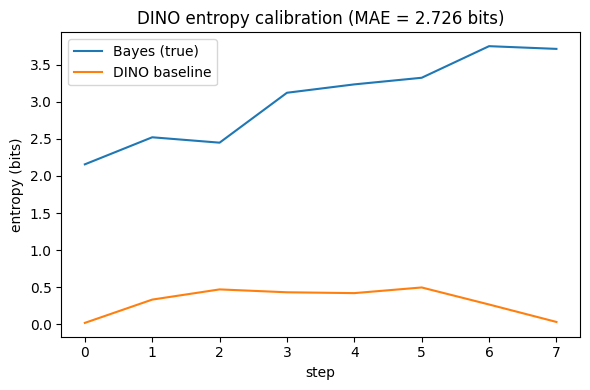

In [ ]:
# --- DINO baseline evaluation ---
if dino is not None:
    ent_true_all = []
    ent_dino_all = []

    for _ in range(DINO_EVAL_SAMPLES):
        shape = rng.choice(SHAPE_KEYS)
        angle = int(rng.choice(ANGLES))
        frames = make_trajectory(shape, angle, steps=N_STEPS)

        p_true = uniform_prior(len(HYP_KEYS))
        p_dino = uniform_prior(len(HYP_KEYS))

        ent_true = []
        ent_dino = []

        for obs in frames:
            p_true = posterior_update(p_true, obs, HYP_LIST, SIGMA_TRUE)
            p_dino = posterior_update_dino(p_dino, obs)
            ent_true.append(entropy_bits(p_true))
            ent_dino.append(entropy_bits(p_dino))

        ent_true_all.append(ent_true)
        ent_dino_all.append(ent_dino)

    ent_true_all = np.array(ent_true_all)
    ent_dino_all = np.array(ent_dino_all)

    mean_true = ent_true_all.mean(axis=0)
    mean_dino = ent_dino_all.mean(axis=0)
    mae = np.mean(np.abs(mean_true - mean_dino))

    plt.figure(figsize=(6, 4))
    plt.plot(mean_true, label='Bayes (true)')
    plt.plot(mean_dino, label='DINO baseline')
    plt.xlabel("step")
    plt.ylabel("entropy (bits)")
    plt.title(f"DINO entropy calibration (MAE = {mae:.3f} bits)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## FM + DINO Fusion Baseline

This combines FM likelihood (dynamics) with DINO similarity (identity).
`FUSION_ALPHA` controls the FM weight; higher means more FM.


In [ ]:
FUSION_ALPHA = 0.6
FUSION_EVAL_SAMPLES = 30
FUSION_SIGMA_DINO = DINO_SIGMA
FUSION_SIGMA_FM = FM_SIGMA

@torch.no_grad()
def dino_log_likelihood_from_emb(obs_emb: torch.Tensor, hyp_emb: torch.Tensor, sigma: float) -> float:
    diff = obs_emb - hyp_emb
    dist = float((diff * diff).sum().item())
    return -dist / (2.0 * sigma * sigma)

@torch.no_grad()
def posterior_update_fusion(prior: np.ndarray, obs_np: np.ndarray, step_frac: float) -> np.ndarray:
    if dino is None or HYP_DINO_EMB is None:
        raise RuntimeError('DINO embeddings not available for fusion.')
    obs_emb = dino_embed_from_np(obs_np)
    logp = []
    for p, ((shape_key, angle), hyp_emb) in zip(prior, zip(HYP_KEYS, HYP_DINO_EMB)):
        ll_fm = fm_log_likelihood(obs_np, shape_key, angle, step_frac, sigma=FUSION_SIGMA_FM)
        ll_dino = dino_log_likelihood_from_emb(obs_emb, hyp_emb, sigma=FUSION_SIGMA_DINO)
        ll = FUSION_ALPHA * ll_fm + (1.0 - FUSION_ALPHA) * ll_dino
        logp.append(math.log(max(p, 1e-12)) + ll)
    return normalize_log_probs(np.array(logp))


In [ ]:
if dino is not None:
    ent_true_all = []
    ent_fuse_all = []
    fracs = np.linspace(0.0, 1.0, N_STEPS)

    for _ in range(FUSION_EVAL_SAMPLES):
        shape = rng.choice(SHAPE_KEYS)
        angle = int(rng.choice(ANGLES))
        frames = make_trajectory(shape, angle, steps=N_STEPS)
        p_true = uniform_prior(len(HYP_KEYS))
        p_fuse = uniform_prior(len(HYP_KEYS))
        ent_true = []
        ent_fuse = []
        for obs, frac in zip(frames, fracs):
            p_true = posterior_update(p_true, obs, HYP_LIST, SIGMA_TRUE)
            p_fuse = posterior_update_fusion(p_fuse, obs, frac)
            ent_true.append(entropy_bits(p_true))
            ent_fuse.append(entropy_bits(p_fuse))
        ent_true_all.append(ent_true)
        ent_fuse_all.append(ent_fuse)
    ent_true_all = np.array(ent_true_all)
    ent_fuse_all = np.array(ent_fuse_all)
    mean_true = ent_true_all.mean(axis=0)
    mean_fuse = ent_fuse_all.mean(axis=0)
    mae = np.mean(np.abs(mean_true - mean_fuse))
    plt.figure(figsize=(6, 4))
    plt.plot(mean_true, label='Bayes (true)')
    plt.plot(mean_fuse, label='FM + DINO fusion')
    plt.xlabel('step')
    plt.ylabel('entropy (bits)')
    plt.title(f'Fusion entropy calibration (MAE = {mae:.3f} bits)')
    plt.legend()
    plt.tight_layout()
    plt.show()
